<a href="https://colab.research.google.com/github/YoungJang-KR/semiconductor-fault-detection/blob/main/01_EDA_PHM18_etching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1단계

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd

In [3]:
# train 폴더의 01_M01_DC_train.csv 파일 분석하기

path_train_01 = '/content/drive/MyDrive/phm18/train/01_M01_DC_train.csv'

df_train_01 = pd.read_csv(path_train_01)

print("행, 렬:", df_train_01.shape)
print("열 항목:", df_train_01.columns.tolist())

행, 렬: (3124704, 24)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION']


In [4]:
# 이번에는 train_ttf 폴더의 01_M01_DC_train.csv 파일 분석하기

path_ttf_01 = '/content/drive/MyDrive/phm18/train_ttf/01_M01_DC_train.csv'

df_ttf_01 = pd.read_csv(path_ttf_01)

print("행, 렬:", df_ttf_01.shape)
print("열 항목:", df_ttf_01.columns.tolist())

행, 렬: (3124704, 4)
열 항목: ['time', 'TTF_FlowCool Pressure Dropped Below Limit', 'TTF_Flowcool Pressure Too High Check Flowcool Pump', 'TTF_Flowcool leak']


In [5]:
# train_ttf 폴더에 있는 파일의 열 이름이 너무 긺으로 수정하기

df_ttf_01 = df_ttf_01.rename( columns={'TTF_FlowCool Pressure Dropped Below Limit': 'TTF_pressure_drop',
                                       'TTF_Flowcool Pressure Too High Check Flowcool Pump': 'TTF_pressure_high',
                                       'TTF_Flowcool leak': 'TTF_leak'})

# 변경이 잘 되었나 확인
print("열 항목:", df_ttf_01.columns.tolist())

열 항목: ['time', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


In [6]:
# 시각화를 위해서 train 폴더의 01 파일과 train_ttf 폴더의 01 파일을 시간에 대해 merge
df_01 = df_train_01.merge(df_ttf_01, on='time')

# merge가 잘 되었나 확인
print("행, 렬:", df_01.shape)
print("열 항목:", df_01.columns.tolist())

행, 렬: (3135742, 27)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


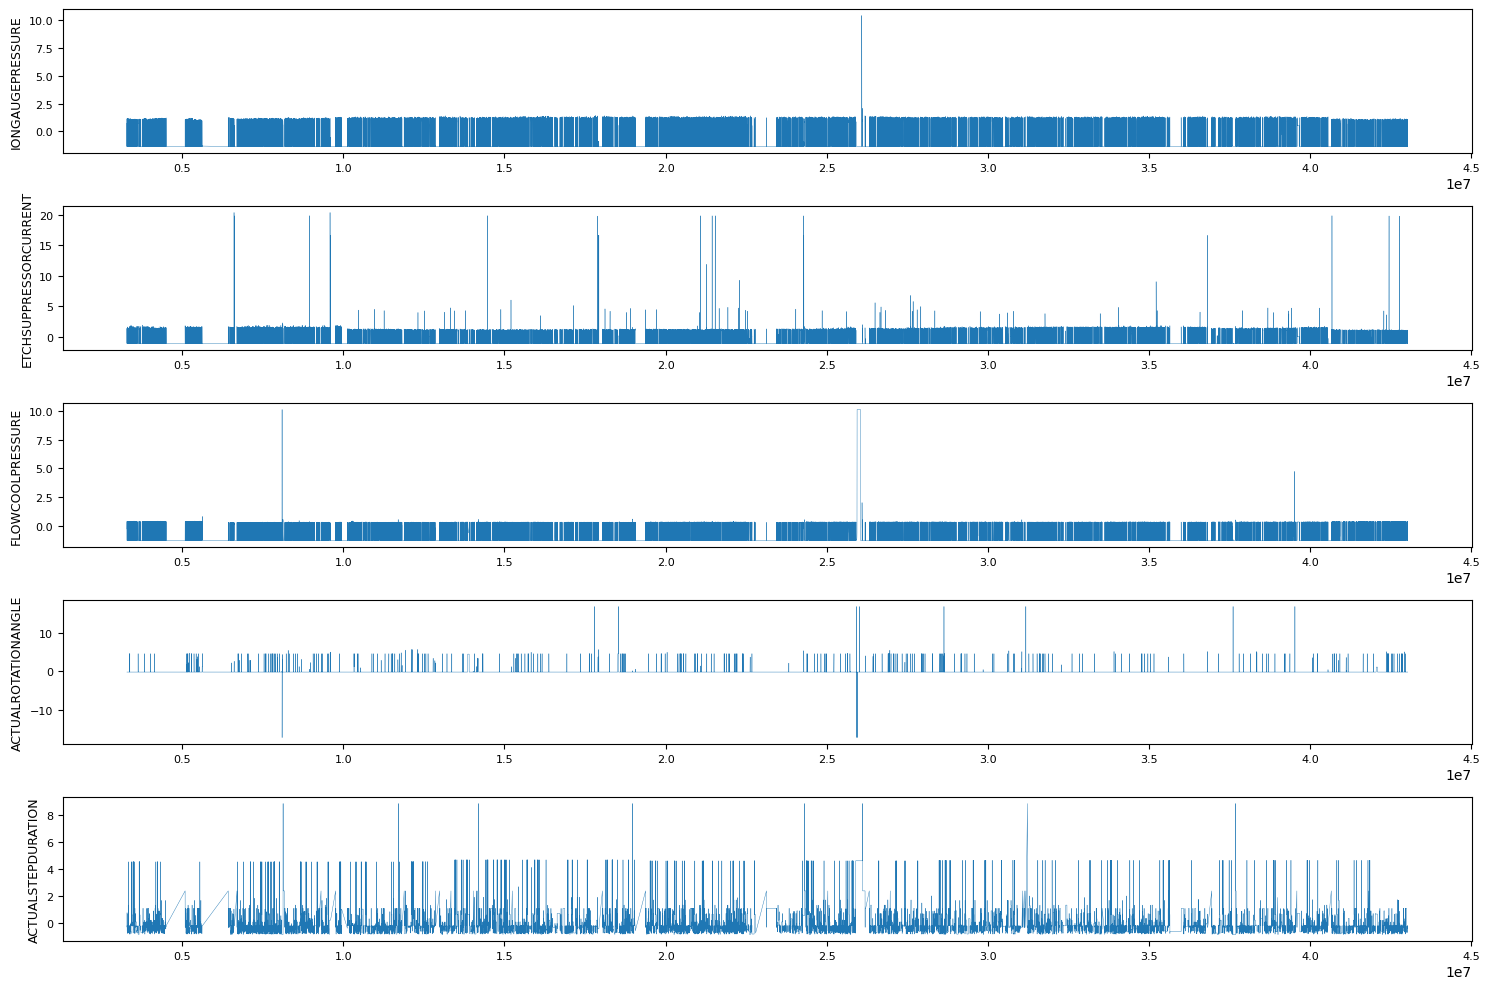

In [7]:
# 센서값에 대한 칼럼을 따로 만들어서 시각화 해보기
sensor_cols = [ 'IONGAUGEPRESSURE',     # 챔버 내부 압력(진공도)
               'ETCHSUPPRESSORCURRENT', # 억제 그리드 전류 - 이상적으로는 0이어야 함
                'FLOWCOOLPRESSURE',     # 기체 헬륨이 든 냉각관의 압력
                'ACTUALROTATIONANGLE',  # 웨이퍼가 실제 회전한 각도
                'ACTUALSTEPDURATION'    # 특정 공정이 실제로 진행된 시간
                ]

import matplotlib.pyplot as plt

fig, axes = plt.subplots( len(sensor_cols), 1, figsize=(15, len(sensor_cols)*2) ) # 여러 그래프를 그릴 때

for i, col in enumerate(sensor_cols):
  axes[i].plot(df_01['time'], df_01[col], linewidth=0.3)
  axes[i].set_ylabel(col, fontsize=9)
  axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

그림이 다소 복잡하지만, 확실한 건 IONGAUGEPRESSURE와 FLOWCOOLPRESSURE 값이 시간이 2.6e7 부근에서 팍 튀는 것(spike)을 확인할 수 있다.

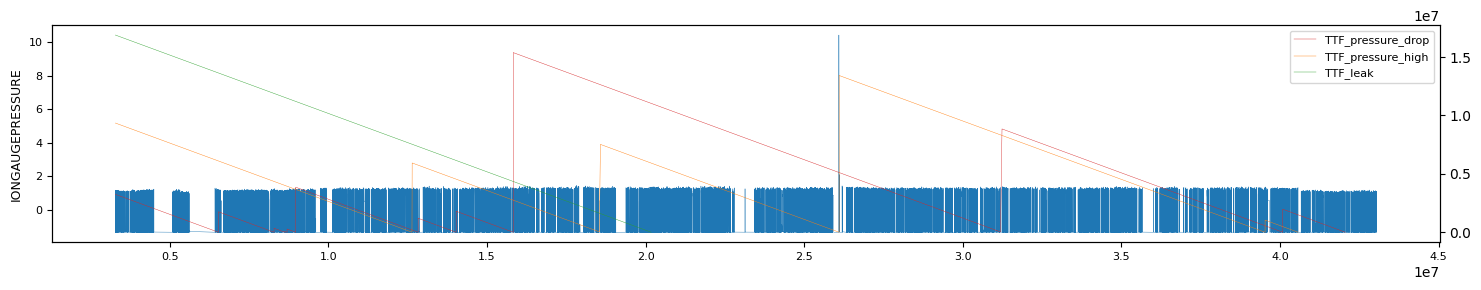

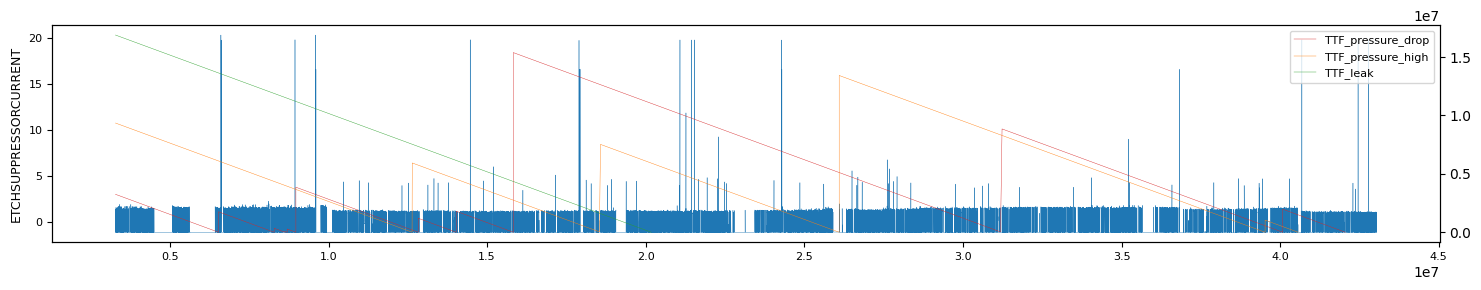

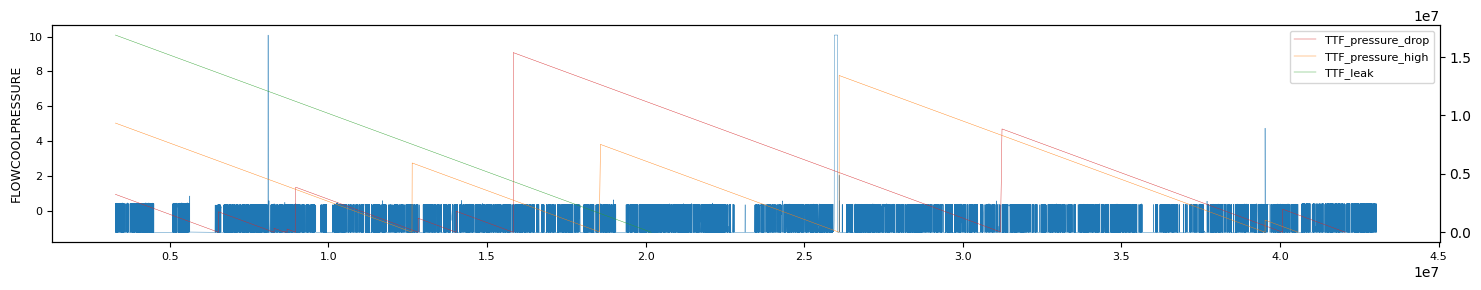

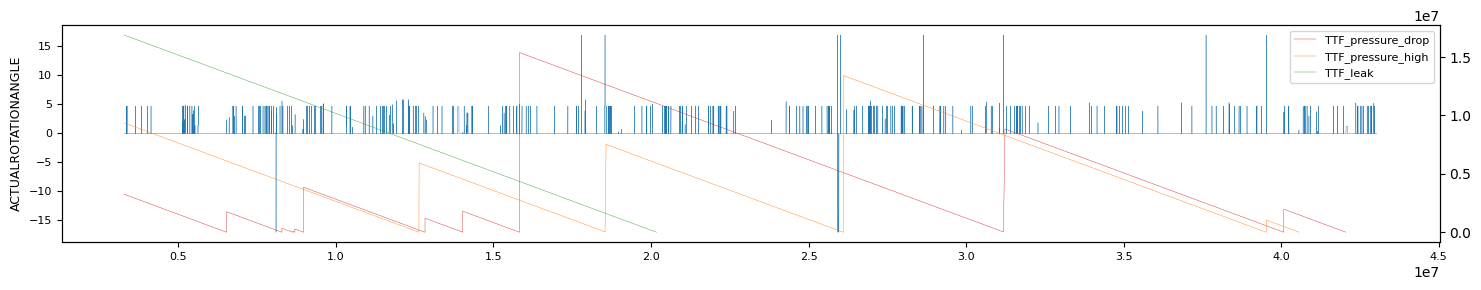

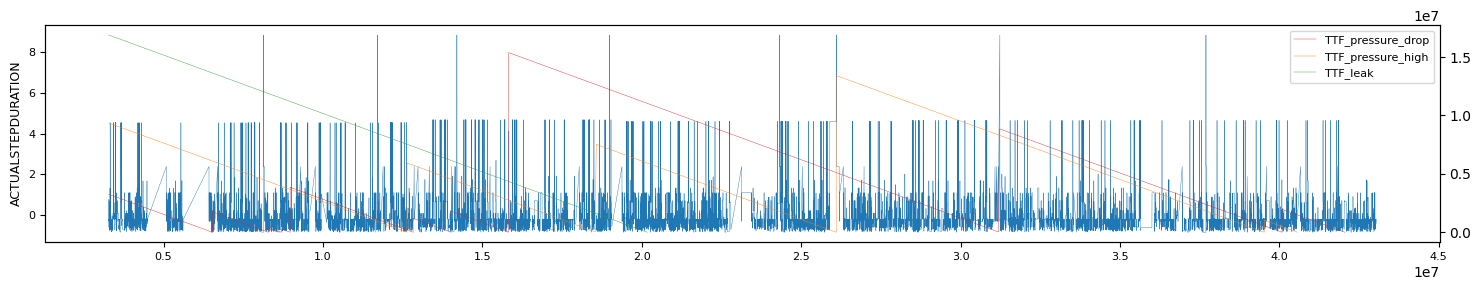

In [8]:
# 고장 변수들(TTF)도 함께 시각화 해보자

for col in sensor_cols:
  fig, ax1 = plt.subplots( figsize=(15, 3) )
  ax1.plot( df_01['time'], df_01[col], linewidth=0.3 )
  ax1.set_ylabel(col, fontsize=9)
  ax1.tick_params(labelsize=8)

  ax2 = ax1.twinx()
  ax2.plot( df_01['time'], df_01['TTF_pressure_drop'], linewidth=0.3,
           color='tab:red', label='TTF_pressure_drop')
  ax2.plot( df_01['time'], df_01['TTF_pressure_high'], linewidth=0.3,
           color='tab:orange', label='TTF_pressure_high')
  ax2.plot( df_01['time'], df_01['TTF_leak'], linewidth=0.3,
           color='tab:green', label='TTF_leak')

  ax2.legend(fontsize=8, loc='upper right')

  plt.tight_layout()
  plt.show()

고장 변수를 같이 그려보면, 확실히 아까 의심했던 2.6e7 부근에서 'TTF_pressure_high' 고장이 났음을 알 수 있다.

In [19]:
# 시각화만으로는 한계가 있으므로, 상관관계 분석을 해보자.

ttf_cols = [ 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak' ]

corr_01 = df_01[ sensor_cols + ttf_cols ].corr()
corr_01_sensor_ttf = corr_01.loc[ sensor_cols, ttf_cols ]
print(corr_01_sensor_ttf)

                       TTF_pressure_drop  TTF_pressure_high  TTF_leak
IONGAUGEPRESSURE                0.010567           0.008017 -0.001035
ETCHSUPPRESSORCURRENT          -0.015696           0.026035  0.090449
FLOWCOOLPRESSURE                0.000423          -0.103868  0.035274
ACTUALROTATIONANGLE            -0.037254           0.001671 -0.031271
ACTUALSTEPDURATION              0.000578          -0.034361  0.005758


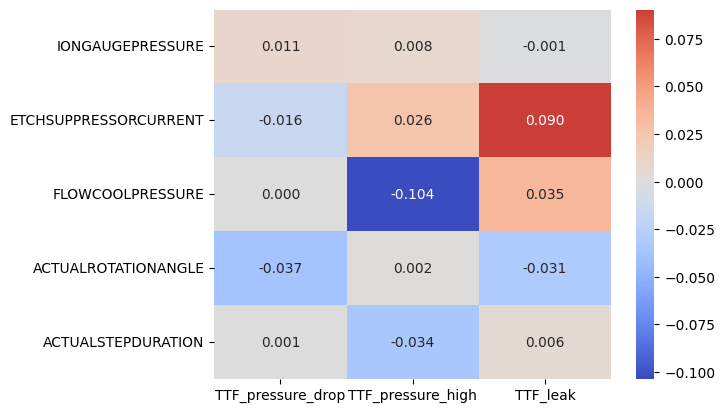

<Figure size 1500x300 with 0 Axes>

In [20]:
# 수치로 보면 감이 안오니 히트맵을 그리자
import seaborn as sns

sns.heatmap(corr_01_sensor_ttf,
            annot = True,
            fmt = '.3f',
            cmap = 'coolwarm', #cbar 아님
            center = 0)

plt.figure(figsize=(15, 3))
plt.tight_layout()
plt.show()

센서값과 고장 변수 간에는 큰 상관관계를 찾을 수 없다. 아마 시간 축은 백만 단위로 긴데 비해 고장이 일어나는 순간은 아주 짧으니 상관관계에 반영이 안된 것일 수 있다.

                         TTF_pressure_drop  TTF_pressure_high  TTF_leak
ETCHBEAMVOLTAGE                   0.013649           0.011060 -0.003264
ETCHBEAMCURRENT                   0.006055           0.007851  0.016645
ETCHSUPPRESSORVOLTAGE            -0.003918           0.013824  0.035809
FLOWCOOLFLOWRATE                  0.008946           0.022253  0.002905
ETCHGASCHANNEL1READBACK           0.003286           0.016508  0.016626
ETCHPBNGASREADBACK                0.007073           0.028553  0.001866
FIXTURETILTANGLE                  0.006168          -0.026848  0.003219
ROTATIONSPEED                     0.086915          -0.014173 -0.159505
FIXTURESHUTTERPOSITION            0.007495          -0.092108  0.002443
ETCHSOURCEUSAGE                  -0.159575           0.047198 -0.273273
ETCHAUXSOURCETIMER                0.313597          -0.439621  0.002556
ETCHAUX2SOURCETIMER               0.110016          -0.465622 -0.110415


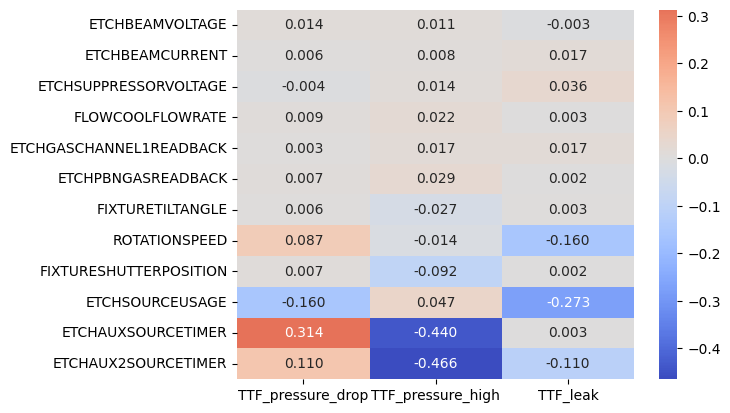

<Figure size 1500x300 with 0 Axes>

In [29]:
control_cols = [ 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT','ETCHSUPPRESSORVOLTAGE',
                'FLOWCOOLFLOWRATE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK',
              'FIXTURETILTANGLE', 'ROTATIONSPEED', 'FIXTURESHUTTERPOSITION',
              'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER' ]


corr_01_control = df_01[ control_cols + ttf_cols ].corr()
corr_01_control_ttf = corr_01_control.loc[control_cols, ttf_cols]
print(corr_01_control_ttf)

sns.heatmap(corr_01_control_ttf,
            annot = True,
            fmt = '.3f',
            cmap = 'coolwarm',
            center = 0)

plt.figure(figsize=(15,3))
plt.tight_layout()
plt.show()

ETCHAUXSOURCETIMER 및 ETCHAUX2SOURCETIMER 두 가지 변수가 TTF_pressure_high와 강한 음의 상관관계를 보임을 알 수 있다. 이는 챔버 쉴드 소모품의 사용 시간이 늘어날수록 냉각관 압력 과다 고장(TTF_pressure_high)이 임박했다는 것으로 해석할 수 있다.